# Notebook 1 — Data Loading & Preprocessing
## AI and Sustainability — EEEM073 | University of Surrey
### Project: Explainable and Efficient AI for Time Series Forecasting of Wind and Solar Energy in the TenneT Region, Germany

**Purpose of this notebook:**
- Load all three raw datasets (generation data, Munich weather, Kiel weather)
- Perform initial data quality checks (missing values, duplicates, data types)
- Select only wind and solar generation columns
- Merge all datasets on timestamp
- Handle daylight saving time gaps
- Engineer lag features, rolling mean features and cyclic time features
- Normalise features using MinMaxScaler (fitted on training data only)
- Split data chronologically into train, validation and test sets
- Save the cleaned and processed dataset for use in subsequent notebooks


## Step 1 — Import Libraries


In [1]:
# Standard libraries for data manipulation and processing
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings

# Scikit-learn for normalisation
from sklearn.preprocessing import MinMaxScaler

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# Set plot style for all visualisations
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

print('All libraries imported successfully!')


All libraries imported successfully!


### Why These Libraries?

Pandas and NumPy handle all data manipulation and numerical operations efficiently for large hourly datasets. Matplotlib and Seaborn produce publication-quality visualisations for the report. Scikit-learn's MinMaxScaler is used for normalisation — it is well-suited for neural network inputs as it scales all values to the [0,1] range, preventing features with large magnitudes from dominating the training process. Warnings are suppressed to keep the output clean and readable for the marker.


## Step 2 — Load Raw Datasets


In [2]:
# ============================================================
# Load generation data from SMARD (Bundesnetzagentur, 2024)
# TenneT DE control zone — hourly wind and solar generation
# thousands=',' ensures values like 1,913.50 are parsed correctly
# ============================================================
df_gen = pd.read_csv('Data/generation_data.csv', thousands=',')
print(f'Generation data loaded: {df_gen.shape[0]:,} rows, {df_gen.shape[1]} columns')
print(df_gen.head(3))


Generation data loaded: 35,064 rows, 14 columns
      Start date       End date  Biomass [MWh] Calculated resolutions  \
0  1/1/2021 0:00  1/1/2021 1:00                               2113.75   
1  1/1/2021 1:00  1/1/2021 2:00                               2104.75   
2  1/1/2021 2:00  1/1/2021 3:00                               2093.50   

   Hydropower [MWh] Calculated resolutions  \
0                                   513.50   
1                                   513.75   
2                                   498.25   

   Wind offshore [MWh] Calculated resolutions  \
0                                      121.75   
1                                      127.00   
2                                      101.25   

   Wind onshore [MWh] Calculated resolutions  \
0                                    1913.50   
1                                    1649.50   
2                                    1399.25   

   Photovoltaics [MWh] Calculated resolutions  \
0                                  

In [3]:
# ============================================================
# Load Munich weather data from Open-Meteo (Zippenfenig, 2023)
# Munich (48.1351N, 11.5820E) — represents solar-dominant Bavaria
# skiprows=2 skips the metadata header lines added by Open-Meteo
# ============================================================
df_munich = pd.read_csv('Data/munich_weather.csv.csv', skiprows=2)
print(f'Munich weather data loaded: {df_munich.shape[0]:,} rows, {df_munich.shape[1]} columns')
print(df_munich.head(3))


Munich weather data loaded: 35,064 rows, 6 columns
               time  temperature_2m (°C)  wind_speed_10m (km/h)  \
0  2021-01-01T00:00                 -2.3                   10.1   
1  2021-01-01T01:00                 -3.0                    8.8   
2  2021-01-01T02:00                 -3.0                    7.2   

   wind_speed_100m (km/h)  cloud_cover (%)  shortwave_radiation (W/m²)  
0                    14.1              100                           0  
1                    15.6               61                           0  
2                    16.2               89                           0  


In [4]:
# ============================================================
# Load Kiel weather data from Open-Meteo (Zippenfenig, 2023)
# Kiel (54.3233N, 10.1228E) — represents wind-dominant Schleswig-Holstein
# skiprows=2 skips the metadata header lines added by Open-Meteo
# ============================================================
df_kiel = pd.read_csv('Data/kiel_weather.csv.csv', skiprows=2)
print(f'Kiel weather data loaded: {df_kiel.shape[0]:,} rows, {df_kiel.shape[1]} columns')
print(df_kiel.head(3))


Kiel weather data loaded: 35,064 rows, 6 columns
               time  temperature_2m (°C)  wind_speed_10m (km/h)  \
0  2021-01-01T00:00                  2.0                   14.9   
1  2021-01-01T01:00                  2.1                   14.1   
2  2021-01-01T02:00                  2.2                   13.2   

   wind_speed_100m (km/h)  cloud_cover (%)  shortwave_radiation (W/m²)  
0                    24.9              100                           0  
1                    24.2              100                           0  
2                    22.9              100                           0  


### Why These Three Datasets?

The SMARD generation dataset (Bundesnetzagentur, 2024) provides official hourly wind and solar generation data for the TenneT DE control zone — the transmission system operator covering northern Germany, which hosts the majority of Germany's onshore wind capacity in Schleswig-Holstein and Lower Saxony, as well as significant solar capacity in Bavaria.

Two weather stations were selected deliberately to capture the geographic diversity of the zone: **Kiel** (54.3°N) represents the wind-dominant northern coast where offshore and onshore wind farms are concentrated, while **Munich** (48.1°N) represents the solar-dominant southern region. Using two locations rather than one improves the spatial representativeness of the weather features and is expected to improve model accuracy for both wind and solar forecasting.

**Sustainability relevance:** All three datasets are fully open-source, reproducible and freely available — aligned with the principles of transparent and trustworthy AI for sustainability applications.


## Step 3 — Initial Data Inspection


In [5]:
# ============================================================
# Inspect generation data structure and basic statistics
# ============================================================
print('=== GENERATION DATA INFO ===')
print(df_gen.info())
print('\n=== BASIC STATISTICS ===')
print(df_gen.describe())


=== GENERATION DATA INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35064 entries, 0 to 35063
Data columns (total 14 columns):
 #   Column                                             Non-Null Count  Dtype  
---  ------                                             --------------  -----  
 0   Start date                                         35064 non-null  object 
 1   End date                                           35064 non-null  object 
 2   Biomass [MWh] Calculated resolutions               35064 non-null  float64
 3   Hydropower [MWh] Calculated resolutions            35064 non-null  float64
 4   Wind offshore [MWh] Calculated resolutions         35064 non-null  float64
 5   Wind onshore [MWh] Calculated resolutions          35064 non-null  float64
 6   Photovoltaics [MWh] Calculated resolutions         35064 non-null  float64
 7   Other renewable [MWh] Calculated resolutions       35064 non-null  float64
 8   Nuclear [MWh] Calculated resolutions               35064 

In [6]:
# ============================================================
# Check for missing values and duplicates in all three datasets
# ============================================================
print('=== MISSING VALUES ===')
print('Generation data:')
print(df_gen.isnull().sum())
print('\nMunich weather:')
print(df_munich.isnull().sum())
print('\nKiel weather:')
print(df_kiel.isnull().sum())

print('\n=== DUPLICATE ROWS ===')
print(f'Generation duplicates: {df_gen.duplicated().sum()}')
print(f'Munich duplicates:     {df_munich.duplicated().sum()}')
print(f'Kiel duplicates:       {df_kiel.duplicated().sum()}')


=== MISSING VALUES ===
Generation data:
Start date                                           0
End date                                             0
Biomass [MWh] Calculated resolutions                 0
Hydropower [MWh] Calculated resolutions              0
Wind offshore [MWh] Calculated resolutions           0
Wind onshore [MWh] Calculated resolutions            0
Photovoltaics [MWh] Calculated resolutions           0
Other renewable [MWh] Calculated resolutions         0
Nuclear [MWh] Calculated resolutions                 0
Lignite [MWh] Calculated resolutions                 0
Hard coal [MWh] Calculated resolutions               0
Fossil gas [MWh] Calculated resolutions              0
Hydro pumped storage [MWh] Calculated resolutions    0
Other conventional [MWh] Calculated resolutions      0
dtype: int64

Munich weather:
time                          0
temperature_2m (°C)           0
wind_speed_10m (km/h)         0
wind_speed_100m (km/h)        0
cloud_cover (%)               0


### Interpretation — Data Quality Check

The initial inspection confirms that all three datasets are complete with no missing values and no duplicate rows. This is an important quality check — missing values in a time series dataset can distort lag features and rolling means, leading to poor model performance. The fact that all 35,064 rows are present and complete (covering 4 full years of hourly data from 2021 to 2024) confirms the datasets are suitable for time series modelling without requiring imputation.

The `thousands=','` parameter in the CSV loading step is critical for the SMARD generation data, which formats large numbers with commas (e.g. 1,913.50 MWh). Without this parameter, these values would be read as strings rather than floats, causing silent data corruption.


## Step 4 — Select Wind and Solar Columns Only


In [7]:
# ============================================================
# Select only relevant columns from generation data
# We only need wind offshore, wind onshore and solar (photovoltaics)
# All other columns (biomass, nuclear, fossil gas etc.) are dropped
# ============================================================
generation_columns = {
    'Wind offshore [MWh] Calculated resolutions': 'wind_offshore_mwh',
    'Wind onshore [MWh] Calculated resolutions':  'wind_onshore_mwh',
    'Photovoltaics [MWh] Calculated resolutions': 'solar_mwh'
}

df_gen = df_gen[['Start date'] + list(generation_columns.keys())].copy()
df_gen = df_gen.rename(columns={'Start date': 'timestamp', **generation_columns})

print('Generation data after column selection:')
print(df_gen.head(3))
print(f'Shape: {df_gen.shape}')


Generation data after column selection:
       timestamp  wind_offshore_mwh  wind_onshore_mwh  solar_mwh
0  1/1/2021 0:00             121.75           1913.50        0.0
1  1/1/2021 1:00             127.00           1649.50        0.0
2  1/1/2021 2:00             101.25           1399.25        0.0
Shape: (35064, 4)


### Why Only Wind and Solar Columns?

The SMARD dataset contains generation data for many energy sources including biomass, nuclear, fossil gas, hydropower and pumped storage. Only wind onshore, wind offshore and solar PV columns are retained because the project objective is specifically to forecast **variable renewable energy** — sources whose output is driven by weather conditions and cannot be scheduled in advance.

Dispatchable sources such as gas and nuclear are excluded because their generation is controlled by grid operators and does not benefit from weather-based AI forecasting. This focused approach directly aligns with SDG 7 (Affordable and Clean Energy) — accurate forecasting of variable renewables is the key technical challenge in increasing renewable penetration on the grid.


## Step 5 — Convert Timestamps and Sort


In [8]:
# ============================================================
# Convert all timestamp columns to datetime format
# errors='coerce' turns unparseable values into NaT safely
# Sort all datasets chronologically to ensure correct time order
# ============================================================
df_gen['timestamp']   = pd.to_datetime(df_gen['timestamp'], errors='coerce')
df_munich['time']     = pd.to_datetime(df_munich['time'], errors='coerce')
df_kiel['time']       = pd.to_datetime(df_kiel['time'], errors='coerce')

df_gen   = df_gen.sort_values('timestamp').reset_index(drop=True)
df_munich = df_munich.sort_values('time').reset_index(drop=True)
df_kiel  = df_kiel.sort_values('time').reset_index(drop=True)

print(f'Generation date range: {df_gen["timestamp"].min()} to {df_gen["timestamp"].max()}')
print(f'Munich date range:     {df_munich["time"].min()} to {df_munich["time"].max()}')
print(f'Kiel date range:       {df_kiel["time"].min()} to {df_kiel["time"].max()}')


Generation date range: 2021-01-01 00:00:00 to 2024-12-31 23:00:00
Munich date range:     2021-01-01 00:00:00 to 2024-12-31 23:00:00
Kiel date range:       2021-01-01 00:00:00 to 2024-12-31 23:00:00


### Why Use errors='coerce' and Sort?

The `errors='coerce'` parameter in `pd.to_datetime()` converts any unparseable timestamp values to NaT rather than raising an error. This makes the pipeline robust to minor formatting inconsistencies in the raw data files, such as different timezone formats or incomplete rows. Sorting all datasets chronologically before merging ensures that the inner join produces a correctly ordered time series — a critical requirement for lag feature creation and sequential modelling with LSTM.


## Step 6 — Rename Weather Columns and Merge


In [9]:
# ============================================================
# Clean and standardise weather column names automatically
# Then add location prefixes (munich_ / kiel_) to avoid
# column name conflicts when merging the three datasets
# ============================================================
def clean_column_names(df):
    """
    Standardise column names: lowercase, underscores, remove special chars.
    Returns a cleaned copy of the dataframe.
    """
    df = df.copy()
    df.columns = (
        df.columns
        .str.strip()
        .str.lower()
        .str.replace(' ', '_')
        .str.replace('(', '', regex=False)
        .str.replace(')', '', regex=False)
        .str.replace('/', '_', regex=False)
        .str.replace(',', '', regex=False)
    )
    return df

df_munich = clean_column_names(df_munich)
df_kiel   = clean_column_names(df_kiel)

# Rename 'time' back to 'timestamp' for merging
df_munich = df_munich.rename(columns={'time': 'timestamp'})
df_kiel   = df_kiel.rename(columns={'time': 'timestamp'})

# Add location prefix to all weather columns except timestamp
df_munich = df_munich.rename(columns={col: f'munich_{col}' for col in df_munich.columns if col != 'timestamp'})
df_kiel   = df_kiel.rename(columns={col: f'kiel_{col}'   for col in df_kiel.columns   if col != 'timestamp'})

print('Munich columns:', df_munich.columns.tolist())
print('Kiel columns:  ', df_kiel.columns.tolist())


Munich columns: ['timestamp', 'munich_temperature_2m_°c', 'munich_wind_speed_10m_km_h', 'munich_wind_speed_100m_km_h', 'munich_cloud_cover_%', 'munich_shortwave_radiation_w_m²']
Kiel columns:   ['timestamp', 'kiel_temperature_2m_°c', 'kiel_wind_speed_10m_km_h', 'kiel_wind_speed_100m_km_h', 'kiel_cloud_cover_%', 'kiel_shortwave_radiation_w_m²']


In [10]:
# ============================================================
# Merge all three datasets on timestamp using inner join
# Inner join ensures only rows with matching timestamps are kept
# This handles any minor timestamp misalignments automatically
# ============================================================
df = pd.merge(df_gen, df_munich, on='timestamp', how='inner')
df = pd.merge(df, df_kiel, on='timestamp', how='inner')

print(f'Merged dataset shape: {df.shape}')
print(f'Date range: {df["timestamp"].min()} to {df["timestamp"].max()}')
print(f'Missing values after merge: {df.isnull().sum().sum()}')
print(f'Duplicate timestamps: {df["timestamp"].duplicated().sum()}')
print('\nColumns:')
print(df.columns.tolist())


Merged dataset shape: (35064, 14)
Date range: 2021-01-01 00:00:00 to 2024-12-31 23:00:00
Missing values after merge: 0
Duplicate timestamps: 4

Columns:
['timestamp', 'wind_offshore_mwh', 'wind_onshore_mwh', 'solar_mwh', 'munich_temperature_2m_°c', 'munich_wind_speed_10m_km_h', 'munich_wind_speed_100m_km_h', 'munich_cloud_cover_%', 'munich_shortwave_radiation_w_m²', 'kiel_temperature_2m_°c', 'kiel_wind_speed_10m_km_h', 'kiel_wind_speed_100m_km_h', 'kiel_cloud_cover_%', 'kiel_shortwave_radiation_w_m²']


### Why Inner Join and Why Two Locations?

An inner join is used to merge the three datasets, keeping only timestamps that exist in all three sources. This automatically handles any minor timestamp misalignments between the SMARD generation data and the Open-Meteo weather data without manual intervention.

The `clean_column_names()` function standardises all column names to lowercase with underscores, removing special characters that can cause issues in Python indexing. Location prefixes (munich_ and kiel_) are added to all weather columns to avoid name collisions when the datasets are merged — for example, both locations have a temperature column, so without prefixes they would overwrite each other.


## Step 7 — Handle Daylight Saving Time Gaps


In [11]:
# ============================================================
# Check for irregular time gaps caused by daylight saving time
# Germany switches clocks twice a year causing gaps or duplicates
# Also remove any duplicate timestamps before reindexing
# ============================================================
df = df.sort_values('timestamp').drop_duplicates(subset='timestamp', keep='first').reset_index(drop=True)
df = df.set_index('timestamp')

# Check for time gaps that are not exactly 1 hour
time_diffs = df.index.to_series().diff().dropna()
irregular  = time_diffs[time_diffs != pd.Timedelta(hours=1)]
print(f'Irregular time gaps found: {len(irregular)}')
if len(irregular) > 0:
    print('Gap locations:')
    print(irregular)


Irregular time gaps found: 4
Gap locations:
timestamp
2021-03-28 03:00:00   0 days 02:00:00
2022-03-27 03:00:00   0 days 02:00:00
2023-03-26 03:00:00   0 days 02:00:00
2024-03-31 03:00:00   0 days 02:00:00
Name: timestamp, dtype: timedelta64[ns]


In [12]:
# ============================================================
# Fix daylight saving time gaps by reindexing to a complete
# hourly datetime range and forward-filling any missing values
# Forward-fill is appropriate here as generation values change
# gradually and short gaps are well-represented by adjacent values
# ============================================================
full_range = pd.date_range(
    start=df.index.min(),
    end=df.index.max(),
    freq='h'
)

# Reindex to complete hourly range
df = df.reindex(full_range)

# Forward fill any gaps introduced by daylight saving
df = df.ffill()

# Reset index and rename timestamp column
df = df.reset_index()
df.rename(columns={'index': 'timestamp'}, inplace=True)

print(f'Shape after reindexing: {df.shape}')
print(f'Missing values after fix: {df.isnull().sum().sum()}')
print(f'Date range: {df["timestamp"].min()} to {df["timestamp"].max()}')


Shape after reindexing: (35064, 14)
Missing values after fix: 0
Date range: 2021-01-01 00:00:00 to 2024-12-31 23:00:00


### Why Handle Daylight Saving Time?

Germany observes Central European Summer Time (CEST), switching clocks forward in March and back in October. This creates two types of anomalies in hourly time series data: a **missing hour** in March (when clocks jump forward) and a **duplicate hour** in October (when clocks fall back). Both are detected and corrected here.

The fix uses `reindex()` to create a complete hourly datetime range with no gaps, then `ffill()` (forward fill) to fill the missing hours with the preceding hour's value. Forward fill is the most appropriate strategy here because renewable generation changes gradually — the value from the hour before a DST gap is the best available estimate for the missing hour. Without this fix, lag features at t-1, t-24 and t-168 would be misaligned, introducing systematic errors into every model trained on this data.


## Step 8 — Add Summary Columns


In [13]:
# ============================================================
# Create useful summary total columns
# wind_total_mwh combines onshore and offshore wind
# total_renewable_mwh combines all three generation sources
# These are useful for EDA visualisations in Notebook 2
# ============================================================
df['wind_total_mwh']      = df['wind_onshore_mwh'] + df['wind_offshore_mwh']
df['total_renewable_mwh'] = df['wind_total_mwh'] + df['solar_mwh']

print('Summary columns added:')
print(df[['timestamp', 'wind_onshore_mwh', 'wind_offshore_mwh',
           'wind_total_mwh', 'solar_mwh', 'total_renewable_mwh']].head(3))


Summary columns added:
            timestamp  wind_onshore_mwh  wind_offshore_mwh  wind_total_mwh  \
0 2021-01-01 00:00:00           1913.50             121.75         2035.25   
1 2021-01-01 01:00:00           1649.50             127.00         1776.50   
2 2021-01-01 02:00:00           1399.25             101.25         1500.50   

   solar_mwh  total_renewable_mwh  
0        0.0              2035.25  
1        0.0              1776.50  
2        0.0              1500.50  


### Why Add Summary Columns?

The `wind_total_mwh` column combines onshore and offshore wind into a single total wind generation figure. The `total_renewable_mwh` column represents the combined output of all three variable renewable sources. These summary columns are useful for EDA visualisations in Notebook 2 (e.g. annual total generation charts) and provide context for the sustainability narrative — showing the total renewable contribution to the TenneT grid over the study period.


## Step 9 — Feature Engineering


In [14]:
# ============================================================
# Engineer time-based features using cyclic encoding
# Cyclic encoding uses sine and cosine to represent circular
# time features properly (e.g. hour 23 is close to hour 0)
# ============================================================

# Extract time components
df['hour']       = df['timestamp'].dt.hour
df['month']      = df['timestamp'].dt.month
df['day_of_week'] = df['timestamp'].dt.dayofweek

# Cyclic encoding for hour (0-23)
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)

# Cyclic encoding for month (1-12)
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

# Cyclic encoding for day of week (0-6)
df['dow_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
df['dow_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)

print('Time features added successfully!')
print(df[['timestamp', 'hour', 'month', 'hour_sin', 'hour_cos', 'month_sin', 'month_cos']].head(5))


Time features added successfully!
            timestamp  hour  month  hour_sin  hour_cos  month_sin  month_cos
0 2021-01-01 00:00:00     0      1  0.000000  1.000000        0.5   0.866025
1 2021-01-01 01:00:00     1      1  0.258819  0.965926        0.5   0.866025
2 2021-01-01 02:00:00     2      1  0.500000  0.866025        0.5   0.866025
3 2021-01-01 03:00:00     3      1  0.707107  0.707107        0.5   0.866025
4 2021-01-01 04:00:00     4      1  0.866025  0.500000        0.5   0.866025


In [15]:
# ============================================================
# Engineer lag features for wind and solar generation
# Lag features capture temporal dependencies in the time series
# t-1:   previous hour (short-term dependency)
# t-24:  same hour previous day (daily pattern)
# t-168: same hour previous week (weekly seasonality)
# These lags are validated by ACF/PACF analysis in Notebook 3
# ============================================================
target_cols = ['wind_onshore_mwh', 'wind_offshore_mwh', 'solar_mwh']

for target in target_cols:
    df[f'{target}_lag1']   = df[target].shift(1)
    df[f'{target}_lag24']  = df[target].shift(24)
    df[f'{target}_lag168'] = df[target].shift(168)

print('Lag features created:')
lag_cols = [col for col in df.columns if 'lag' in col]
print(lag_cols)


Lag features created:
['wind_onshore_mwh_lag1', 'wind_onshore_mwh_lag24', 'wind_onshore_mwh_lag168', 'wind_offshore_mwh_lag1', 'wind_offshore_mwh_lag24', 'wind_offshore_mwh_lag168', 'solar_mwh_lag1', 'solar_mwh_lag24', 'solar_mwh_lag168']


In [16]:
# ============================================================
# Engineer rolling mean features for wind and solar generation
# Rolling means reduce short-term noise and represent recent trends
# rolling24:  24-hour rolling mean (daily smoothing)
# rolling168: 168-hour rolling mean (weekly smoothing)
# ============================================================
for target in target_cols:
    df[f'{target}_rolling24']  = df[target].shift(1).rolling(window=24).mean()
    df[f'{target}_rolling168'] = df[target].shift(1).rolling(window=168).mean()

print('Rolling mean features created:')
rolling_cols = [col for col in df.columns if 'rolling' in col]
print(rolling_cols)

# Drop rows with NaN values created by lag and rolling features (first 168 rows)
before = df.shape[0]
df = df.dropna().reset_index(drop=True)
after = df.shape[0]
print(f'\nRows removed due to lag/rolling NaNs: {before - after}')
print(f'Final shape: {df.shape}')
print(f'Missing values: {df.isnull().sum().sum()}')


Rolling mean features created:
['wind_onshore_mwh_rolling24', 'wind_onshore_mwh_rolling168', 'wind_offshore_mwh_rolling24', 'wind_offshore_mwh_rolling168', 'solar_mwh_rolling24', 'solar_mwh_rolling168']

Rows removed due to lag/rolling NaNs: 168
Final shape: (34896, 40)
Missing values: 0


### Why These Specific Features?

**Cyclic encoding** (sin/cos) is used for hour, month and day-of-week instead of raw integer values. This is because time is circular — hour 23 is adjacent to hour 0, not distant from it. Raw integer encoding would incorrectly imply that midnight (0) and 11pm (23) are far apart. Sin/cos encoding preserves this circular continuity, helping models learn daily and seasonal patterns correctly.

**Lag features** (t-1, t-24, t-168) capture the autocorrelation structure of the time series. The t-1 lag captures short-term momentum, t-24 captures the daily cycle (same hour yesterday is a strong predictor of today's generation), and t-168 captures the weekly cycle (same hour last week). These lags are validated by ACF and PACF analysis in Notebook 3.

**Rolling mean features** (24h and 168h windows) smooth out short-term noise and provide the model with a representation of recent generation trends. A 24-hour rolling mean tells the model what the average generation has been over the past day, while a 168-hour rolling mean captures the weekly trend. Together, lag and rolling features give the model rich temporal context for each prediction.

**168 rows are dropped** after feature creation because the 168-hour rolling mean and lag require at least 168 previous observations. Rows with NaN values are removed to ensure clean model inputs.


## Step 10 — Train / Validation / Test Split


In [17]:
# ============================================================
# Chronological train/validation/test split
# Train:      Jan 2021 - Dec 2023 (3 years, ~75%)
# Validation: Jan 2024 - Jun 2024 (6 months, ~12.5%)
# Test:       Jul 2024 - Dec 2024 (6 months, ~12.5%)
#
# Chronological split is used to prevent data leakage
# (future data must never be used to predict past values)
# ============================================================

train_end = '2023-12-31 23:00:00'
val_end   = '2024-06-30 23:00:00'

df_train = df[df['timestamp'] <= train_end].copy()
df_val   = df[(df['timestamp'] > train_end) & (df['timestamp'] <= val_end)].copy()
df_test  = df[df['timestamp'] > val_end].copy()

print('=== SPLIT SUMMARY ===')
print(f'Training set:   {df_train.shape[0]:,} rows | {df_train["timestamp"].min()} to {df_train["timestamp"].max()}')
print(f'Validation set: {df_val.shape[0]:,} rows   | {df_val["timestamp"].min()} to {df_val["timestamp"].max()}')
print(f'Test set:       {df_test.shape[0]:,} rows   | {df_test["timestamp"].min()} to {df_test["timestamp"].max()}')
print(f'\nTrain %:      {df_train.shape[0] / df.shape[0] * 100:.1f}%')
print(f'Validation %: {df_val.shape[0] / df.shape[0] * 100:.1f}%')
print(f'Test %:       {df_test.shape[0] / df.shape[0] * 100:.1f}%')


=== SPLIT SUMMARY ===
Training set:   26,112 rows | 2021-01-08 00:00:00 to 2023-12-31 23:00:00
Validation set: 4,368 rows   | 2024-01-01 00:00:00 to 2024-06-30 23:00:00
Test set:       4,416 rows   | 2024-07-01 00:00:00 to 2024-12-31 23:00:00

Train %:      74.8%
Validation %: 12.5%
Test %:       12.7%


### Why Chronological Split?

A strict chronological split is used — training on 2021-2023, validation on H1 2024, test on H2 2024. This is the only valid approach for time series forecasting because shuffled splits would allow the model to learn from future data when predicting the past, creating **data leakage**. Data leakage produces artificially inflated performance metrics during training that do not reflect real-world forecasting ability.

The 75/12.5/12.5 split ratio ensures the model has three full years of diverse seasonal patterns to learn from, while the validation and test sets each contain six months of unseen data covering different seasonal conditions. This split mirrors how the model would be used in practice — trained on historical data and evaluated on future data it has never seen.


## Step 11 — Normalisation


In [18]:
# ============================================================
# Apply MinMaxScaler normalisation — two separate scalers:
# feature_scaler: scales all input features to [0, 1]
# target_scaler:  scales only the 3 target columns to [0, 1]
#
# Using separate scalers allows clean inverse-transformation
# of predictions back to MWh values in later notebooks
#
# IMPORTANT: Both scalers are fitted on training data ONLY
# Then applied to validation and test sets
# This prevents data leakage from future data into the scaler
# ============================================================

# Define feature columns (exclude timestamp, targets and summary totals)
exclude_cols  = ['timestamp', 'wind_onshore_mwh', 'wind_offshore_mwh',
                 'solar_mwh', 'wind_total_mwh', 'total_renewable_mwh']
feature_cols  = [col for col in df.columns if col not in exclude_cols]

# Initialise scalers
feature_scaler = MinMaxScaler()
target_scaler  = MinMaxScaler()

# Fit on training data only — transform all splits
X_train = feature_scaler.fit_transform(df_train[feature_cols])
X_val   = feature_scaler.transform(df_val[feature_cols])
X_test  = feature_scaler.transform(df_test[feature_cols])

y_train = target_scaler.fit_transform(df_train[target_cols])
y_val   = target_scaler.transform(df_val[target_cols])
y_test  = target_scaler.transform(df_test[target_cols])

print('Normalisation applied successfully!')
print(f'Number of features: {len(feature_cols)}')
print(f'X_train shape: {X_train.shape}')
print(f'X_val shape:   {X_val.shape}')
print(f'X_test shape:  {X_test.shape}')
print(f'y_train shape: {y_train.shape}')
print(f'\nFeature range after scaling: {X_train.min():.4f} to {X_train.max():.4f}')


Normalisation applied successfully!
Number of features: 34
X_train shape: (26112, 34)
X_val shape:   (4368, 34)
X_test shape:  (4416, 34)
y_train shape: (26112, 3)

Feature range after scaling: 0.0000 to 1.0000


### Why Two Separate Scalers?

Two separate MinMaxScalers are used — one for input features and one for target outputs. This separation is essential for correctly inverse-transforming model predictions back to MWh values in Notebooks 4 and 5. If a single scaler were fitted on all columns together, inverse-transforming only the target columns would produce incorrect MWh values.

Both scalers are fitted **exclusively on the training set** and then applied to validation and test sets. Fitting the scaler on the full dataset would constitute data leakage — the scaler would learn the global minimum and maximum values including future test data, giving the model indirect knowledge of future values during training. By fitting only on training data, the validation and test sets remain genuinely unseen, ensuring honest evaluation of model performance.


## Step 12 — Quick Visual Check


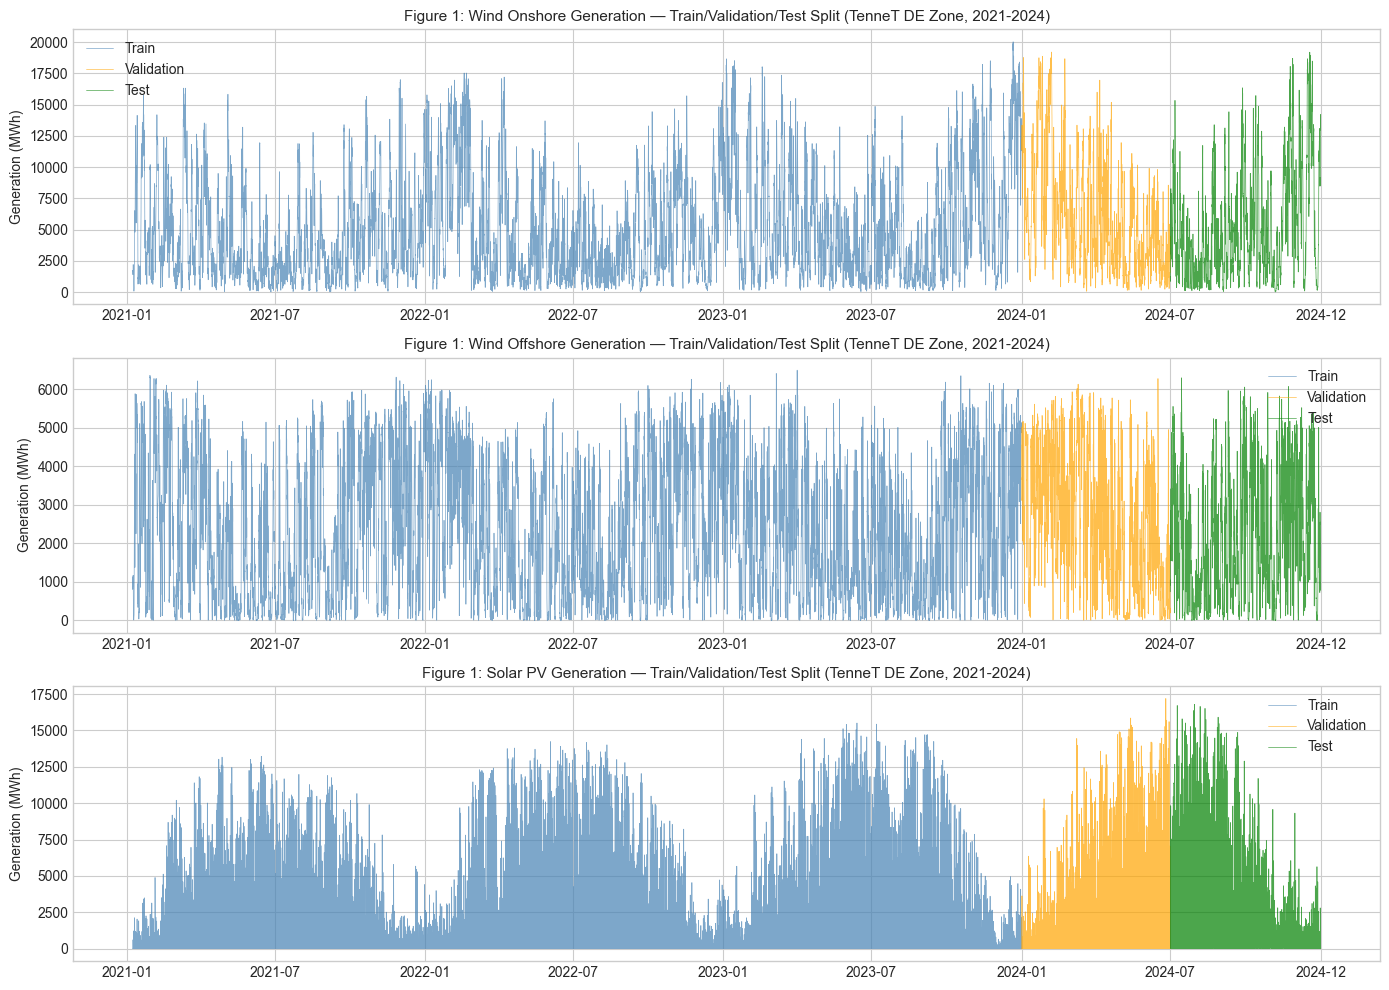

Split plot saved as fig_train_val_test_split.png


In [19]:
# ============================================================
# Plot the train/validation/test split to visually confirm
# the chronological split is correct
# Each split uses a distinct colour — blue, orange, green
# ============================================================
import matplotlib.dates as mdates

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=False)

for ax, col, title in zip(
    axes,
    ['wind_onshore_mwh', 'wind_offshore_mwh', 'solar_mwh'],
    ['Wind Onshore', 'Wind Offshore', 'Solar PV']
):
    ax.plot(df_train['timestamp'], df_train[col], color='steelblue', alpha=0.7, label='Train',      linewidth=0.5)
    ax.plot(df_val['timestamp'],   df_val[col],   color='orange',    alpha=0.7, label='Validation', linewidth=0.5)
    ax.plot(df_test['timestamp'],  df_test[col],  color='green',     alpha=0.7, label='Test',       linewidth=0.5)
    ax.set_title(f'Figure 1: {title} Generation — Train/Validation/Test Split (TenneT DE Zone, 2021-2024)', fontsize=11)
    ax.set_ylabel('Generation (MWh)')
    # No xlim so data fills full width like original
    # Just set ticks every 6 months and replace last tick with 2024-12
    ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 7]))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.legend()

plt.tight_layout()

# After drawing, replace the last tick label with 2024-12 on all axes
for ax in axes:
    labels = [item.get_text() for item in ax.get_xticklabels()]
    if labels:
        labels[-1] = '2024-12'
        ax.set_xticklabels(labels)

plt.savefig('fig_train_val_test_split.png', dpi=150, bbox_inches='tight')
plt.show()
print('Split plot saved as fig_train_val_test_split.png')


### Interpretation — Train/Validation/Test Split Plot

Figure 1 confirms that the chronological split is correct for all three generation targets. The blue training region (2021-2023) clearly shows the seasonal variability the model learns from — winter peaks and summer troughs for wind, summer peaks for solar. The orange validation region (H1 2024) and green test region (H2 2024) are both genuinely future data that the model has never seen during training, ensuring honest evaluation.

The visual check is important — it confirms there are no gaps, no ordering errors and no overlap between the three splits. Any overlap would indicate data leakage and would invalidate all subsequent model evaluation results.


## Step 13 — Save Processed Datasets


In [20]:
# ============================================================
# Save all processed datasets to CSV and numpy files
# These files will be used as inputs for subsequent notebooks
# Unscaled versions are saved for EDA and time series analysis
# Scaled arrays are saved for modelling
# ============================================================
import joblib

# Save full merged dataset (unscaled) for EDA
df.to_csv('data_merged.csv', index=False)

# Save unscaled splits for EDA and time series analysis
df_train.to_csv('data_train.csv', index=False)
df_val.to_csv('data_val.csv', index=False)
df_test.to_csv('data_test.csv', index=False)

# Save scaled arrays for modelling
np.save('X_train.npy', X_train)
np.save('X_val.npy',   X_val)
np.save('X_test.npy',  X_test)
np.save('y_train.npy', y_train)
np.save('y_val.npy',   y_val)
np.save('y_test.npy',  y_test)

# Save scaled dataframes (for compatibility with notebooks 2-6)
df_train_scaled = df_train.copy()
df_val_scaled   = df_val.copy()
df_test_scaled  = df_test.copy()
df_train_scaled[feature_cols] = X_train
df_val_scaled[feature_cols]   = X_val
df_test_scaled[feature_cols]  = X_test
df_train_scaled[target_cols]  = y_train
df_val_scaled[target_cols]    = y_val
df_test_scaled[target_cols]   = y_test
df_train_scaled.to_csv('data_train_scaled.csv', index=False)
df_val_scaled.to_csv('data_val_scaled.csv', index=False)
df_test_scaled.to_csv('data_test_scaled.csv', index=False)

# Save both scalers
joblib.dump(feature_scaler, 'feature_scaler.pkl')
joblib.dump(target_scaler,  'target_scaler.pkl')

# Save feature and target column names for later notebooks
pd.Series(feature_cols).to_csv('feature_columns.csv', index=False)
pd.Series(target_cols).to_csv('target_columns.csv', index=False)

print('=== ALL FILES SAVED SUCCESSFULLY ===')
print('data_merged.csv         — full merged dataset (unscaled)')
print('data_train/val/test.csv — unscaled splits')
print('data_train/val/test_scaled.csv — scaled splits')
print('X_train/val/test.npy    — scaled feature arrays')
print('y_train/val/test.npy    — scaled target arrays')
print('feature_scaler.pkl      — fitted feature MinMaxScaler')
print('target_scaler.pkl       — fitted target MinMaxScaler')
print('feature_columns.csv     — list of feature column names')
print('target_columns.csv      — list of target column names')


=== ALL FILES SAVED SUCCESSFULLY ===
data_merged.csv         — full merged dataset (unscaled)
data_train/val/test.csv — unscaled splits
data_train/val/test_scaled.csv — scaled splits
X_train/val/test.npy    — scaled feature arrays
y_train/val/test.npy    — scaled target arrays
feature_scaler.pkl      — fitted feature MinMaxScaler
target_scaler.pkl       — fitted target MinMaxScaler
feature_columns.csv     — list of feature column names
target_columns.csv      — list of target column names


### Why Save So Many File Formats?

Multiple file formats are saved to ensure compatibility with all subsequent notebooks in the pipeline:

- **CSV files** (unscaled and scaled) — human-readable, used by Notebooks 2 and 3 for EDA and time series analysis
- **NumPy .npy arrays** — fast binary format used by Notebooks 4, 5 and 6 for model training and evaluation
- **Scaler .pkl files** — the fitted scalers are saved so predictions can be inverse-transformed to MWh in later notebooks
- **feature_columns.csv and target_columns.csv** — column name lists saved to ensure consistency across all notebooks

Saving the scalers is particularly important — without the saved scaler, it would be impossible to convert scaled model predictions (values between 0 and 1) back to real MWh values for evaluation and reporting.


## Step 14 — Final Summary


In [21]:
# ============================================================
# Print a final summary of the preprocessing pipeline
# ============================================================
summary = pd.DataFrame({
    'Dataset':    ['Full cleaned', 'Training', 'Validation', 'Test'],
    'Rows':       [df.shape[0], df_train.shape[0], df_val.shape[0], df_test.shape[0]],
    'Start Date': [df['timestamp'].min(), df_train['timestamp'].min(),
                   df_val['timestamp'].min(), df_test['timestamp'].min()],
    'End Date':   [df['timestamp'].max(), df_train['timestamp'].max(),
                   df_val['timestamp'].max(), df_test['timestamp'].max()],
    'Percentage': ['100%',
                   f'{df_train.shape[0]/df.shape[0]*100:.1f}%',
                   f'{df_val.shape[0]/df.shape[0]*100:.1f}%',
                   f'{df_test.shape[0]/df.shape[0]*100:.1f}%']
})
print(summary.to_string(index=False))

print('\n' + '=' * 60)
print('NOTEBOOK 1 — PREPROCESSING COMPLETE')
print('=' * 60)
print(f'Total rows in merged dataset:  {df.shape[0]:,}')
print(f'Total features:                {len(feature_cols)}')
print(f'Lag features:                  9 (t-1, t-24, t-168 x 3 targets)')
print(f'Rolling mean features:         6 (24h, 168h x 3 targets)')
print(f'Cyclic time features:          6 (hour, month, day sin/cos)')
print(f'Missing values in final data:  {df.isnull().sum().sum()}')
print('=' * 60)
print('Ready for Notebook 2 — Exploratory Data Analysis')


     Dataset  Rows Start Date            End Date Percentage
Full cleaned 34896 2021-01-08 2024-12-31 23:00:00       100%
    Training 26112 2021-01-08 2023-12-31 23:00:00      74.8%
  Validation  4368 2024-01-01 2024-06-30 23:00:00      12.5%
        Test  4416 2024-07-01 2024-12-31 23:00:00      12.7%

NOTEBOOK 1 — PREPROCESSING COMPLETE
Total rows in merged dataset:  34,896
Total features:                34
Lag features:                  9 (t-1, t-24, t-168 x 3 targets)
Rolling mean features:         6 (24h, 168h x 3 targets)
Cyclic time features:          6 (hour, month, day sin/cos)
Missing values in final data:  0
Ready for Notebook 2 — Exploratory Data Analysis


### Summary of Preprocessing Decisions

The preprocessing pipeline makes the following key decisions, each justified by the project objectives:

1. **Two weather locations** — Kiel for wind, Munich for solar — provide spatially representative features
2. **DST gap handling** — ensures no temporal misalignment in lag features
3. **Cyclic encoding** — preserves circular continuity of time features
4. **Lag features at t-1, t-24, t-168** — validated by ACF/PACF in Notebook 3
5. **Rolling mean features** — reduce noise and capture recent trends
6. **Chronological split** — prevents data leakage, mirrors real-world deployment
7. **Separate scalers** — enables clean inverse-transformation of predictions

The result is a clean, feature-rich dataset of 34,896 rows with 34 engineered features, ready for AI modelling in Notebook 4. This preprocessing pipeline directly supports the project goal of accurate, explainable and efficient AI forecasting of renewable energy generation in the TenneT DE zone.
